In [1]:
# | default_exp utils

# Model Training

> Training an MLP on a simple binary classification task

Imports

In [2]:
from learningdynamics.models import MLP, init_weights
from learningdynamics.datasets import YinYangDataset
from learningdynamics.visualization import plot_decision_boundary_movie
import matplotlib.pyplot as plt
import matplotlib
from torch.nn import CrossEntropyLoss
from safetensors.torch import save_model
from torch.optim import SGD

In [3]:
# | export
import os
from torch.nn import Module
from torch.utils.data import DataLoader, Dataset
import json
from torcheval.metrics import MulticlassAccuracy

Notebook configuration

In [4]:
# Dataset Settings
NUM_SAMPLES = 2_000
NEGATIVE_LABEL = False

# Visualization
FIGSIZE = (5, 5)
matplotlib.rc("figure", figsize=FIGSIZE)

# MLP settings
HIDDEN_NEURONS = [6, 6, 3, 3]  # only valid for HiddenLayerModel
NONLINEARITY = "tanh" if NEGATIVE_LABEL else "relu"

# Model training settings
BATCH_SIZE = 2_000
NUM_EPOCHS = 30_000
LEARNING_RATE = 1e-1
PRINT_FREQ = 500

Define a YinYang dataset

In [5]:
dataset = YinYangDataset(
    num_samples=NUM_SAMPLES,
    negative_label=NEGATIVE_LABEL,
)

Visualize the dataset as a sanity check.

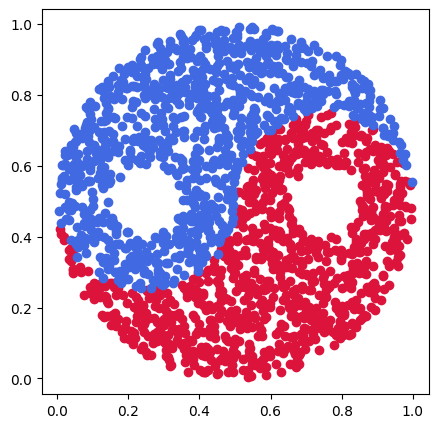

In [6]:
# Plot data
plt.scatter(
    *dataset.features[dataset.labels.squeeze() == 0].T, color="crimson", label="0"
)
plt.scatter(
    *dataset.features[dataset.labels.squeeze() == 1].T, color="royalblue", label="1"
)

Define a MLP model

In [7]:
model = MLP(
    config=HIDDEN_NEURONS,
    in_features=dataset.features.shape[-1],
    nonlinearity=NONLINEARITY,
)
model.apply(init_weights)

MLP(
  (features): Sequential(
    (0): Linear(in_features=2, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=3, bias=True)
    (5): ReLU()
    (6): Linear(in_features=3, out_features=3, bias=True)
    (7): ReLU()
    (8): Linear(in_features=3, out_features=2, bias=True)
  )
)

Setup model training

In [17]:
dataloader = DataLoader(dataset=dataset, shuffle=True, batch_size=BATCH_SIZE)
criterion = CrossEntropyLoss()  # Use CrossEntropyLoss for multi-class classification
optimizer = SGD(model.parameters(), lr=LEARNING_RATE * 0.2, weight_decay=1e-3)

Train the model.

In [ ]:
device = "cuda:0"
model.to(device=device)
model.train()

loss_vector = []
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0  # Track loss within the epoch

    for batch_idx, (input, label) in enumerate(dataloader):
        input, label = input.to(device), label.to(device)
        label = label.squeeze()

        optimizer.zero_grad()
        output = model(input)

        loss = criterion(output, label.long())
        loss.backward()
        optimizer.step()

        running_loss += loss.item()  # Accumulate loss

    epoch_loss = running_loss / len(dataloader)  # Average loss over all batches
    loss_vector.append(epoch_loss)  # Store loss for later analysis

    if (epoch + 1) % PRINT_FREQ == 0:
        print(f"Epoch {epoch + 1}/{NUM_EPOCHS}, Loss: {epoch_loss:.4f}")

Visualize the model's final decision boundary

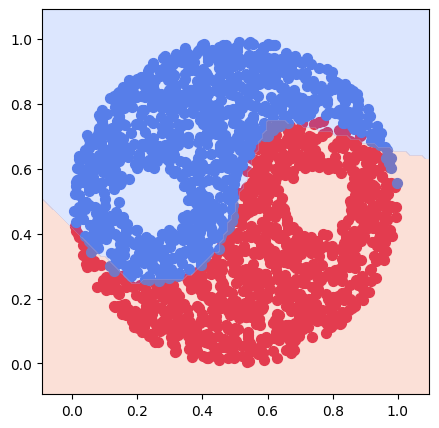

In [19]:
plot_decision_boundary_movie(
    model,
    [model.state_dict()],
    dataset.features,
    dataset.labels.squeeze(),
    figsize=FIGSIZE,
    labels=[0, 1],
)

Test the model

In [20]:
# | export
def compute_model_accuracy(
    model: Module,  # Model
    dataset: Dataset,  # Dataset
):
    dataloader = DataLoader(dataset, batch_size=256)
    metric = MulticlassAccuracy()
    for batch in dataloader:
        image, target = batch
        output = model(image)
        metric.update(output, target.squeeze())

    return metric.compute()

Save the model using `safetensors`

In [21]:
metadata_dict = {
    "config": str(HIDDEN_NEURONS),
    "dataset": str(dataset),
    "nonlinearity": NONLINEARITY,
}
save_model(model, "../saved_weights/model.safetensors", metadata=metadata_dict)

Parser for future use

In [22]:
# | export
def safetensors_metadata_parser(
    file_path: str,  # thing
):
    "Parse the metadata from safetensors file"
    header_size = 8
    meta_data = {}
    if os.stat(file_path).st_size > header_size:
        with open(file_path, "rb") as f:
            b8 = f.read(header_size)
            if len(b8) == header_size:
                header_len = int.from_bytes(b8, "little", signed=False)
                headers = f.read(header_len)
                if len(headers) == header_len:
                    meta_data = sorted(
                        json.loads(headers.decode("utf-8"))
                        .get("__metadata__", meta_data)
                        .items()
                    )
    meta_data_dict = {}
    for k, v in meta_data:
        meta_data_dict[k] = v
    return meta_data_dict

In [23]:
# | export
def getActivation(
    name: str,  # name of layer
    activation_dict: dict,  # dict to store activations,
    detach: bool = True,  # do not keep computational graph
):
    def hook(model, input, output):
        if detach:
            activation_dict[name] = output.detach()
        else:
            activation_dict[name] = output

    return hook